## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\rishi\Downloads\student_performance_dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

First 5 rows:
   Student_ID  Gender  Study_Hours  Attendance  Assignment_Score  Math_Score  \
0           1    Male            7        90.4             100.0        91.0   
1           2  Female            4        68.8              71.1        66.0   
2           3    Male            8        69.5              96.9        83.0   
3           4    Male            5        82.5              75.1        77.0   
4           5    Male            7        72.8              83.8        80.0   

   Science_Score  English_Score  Final_Score Performance  
0           79.0           96.0         92.2   Excellent  
1           69.0           78.0         69.7        Good  
2           76.0           70.0         75.3   Very Good  
3           97.0           70.0         79.7   Very Good  
4           85.0           71.0         82.8   Very Good  

Dataset Shape:
(1000, 10)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 column

## Data Cleaning

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Student_ID          0
Gender              0
Study_Hours         0
Attendance          0
Assignment_Score    0
Math_Score          0
Science_Score       0
English_Score       0
Final_Score         0
Performance         0
dtype: int64


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Exploratory Data Analysis

In [8]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Math_Score,Science_Score,English_Score,Final_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,5.448000,79.850300,81.516100,71.455000,72.565000,70.485000,72.624300
std,288.819436,2.912005,11.699905,13.355175,15.053657,14.438915,13.987617,12.441809
min,1.000000,1.000000,40.000000,41.600000,25.000000,27.000000,20.000000,37.100000
25%,250.750000,3.000000,72.200000,71.500000,61.000000,62.000000,61.000000,63.300000
50%,500.500000,5.000000,80.300000,82.050000,72.000000,73.000000,70.000000,73.050000
75%,750.250000,8.000000,88.800000,93.700000,82.000000,83.000000,81.000000,82.000000
max,1000.000000,10.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [9]:
print("Average Math Score:", df["Math_Score"].mean())
print("Average Science Score:", df["Science_Score"].mean())
print("Average English Score:", df["English_Score"].mean())
print("Average Final Score:", df["Final_Score"].mean())
print("Average Attendance:", df["Attendance"].mean())

Average Math Score: 71.455
Average Science Score: 72.565
Average English Score: 70.485
Average Final Score: 72.62429999999999
Average Attendance: 79.8503


In [10]:
top_students = df.sort_values(
    by="Final_Score",
    ascending=False
).head(10)

top_students[
    ["Student_ID", "Final_Score", "Performance"]
]

,Student_ID,Final_Score,Performance
394,395,100.0,Excellent
809,810,99.6,Excellent
536,537,99.5,Excellent
325,326,99.5,Excellent
469,470,99.1,Excellent
758,759,98.9,Excellent
361,362,98.8,Excellent
393,394,98.6,Excellent
797,798,97.9,Excellent
639,640,97.8,Excellent


In [11]:
print("\nPerformance Distribution:")
print(df["Performance"].value_counts())


Performance Distribution:
Performance
Good                 374
Very Good            360
Average              177
Excellent             87
Needs Improvement      2
Name: count, dtype: int64


In [12]:
subjects = [
    "Math_Score",
    "Science_Score",
    "English_Score"
]

average_scores = df[subjects].mean()

average_scores

Math_Score       71.455
Science_Score    72.565
English_Score    70.485
dtype: float64

## Data Visualization

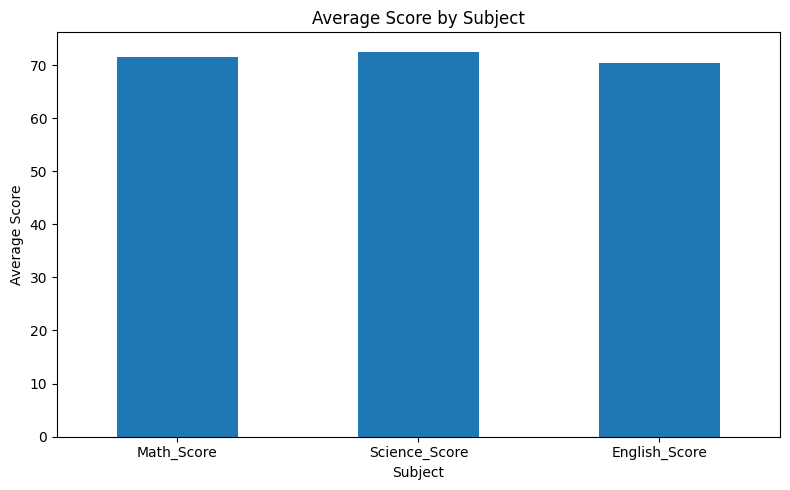

In [16]:
plt.figure(figsize=(8, 5))

average_scores.plot(kind="bar")

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

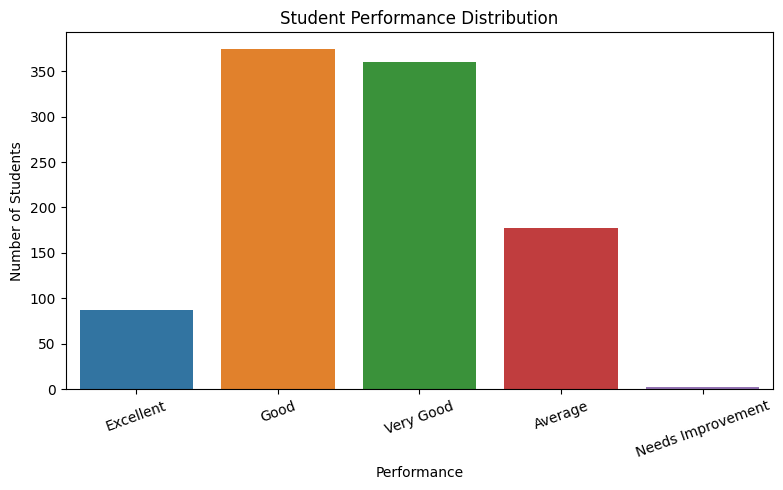

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Performance"
)

plt.title("Student Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


In [27]:
# STUDY HOURS VS FINAL SCORE

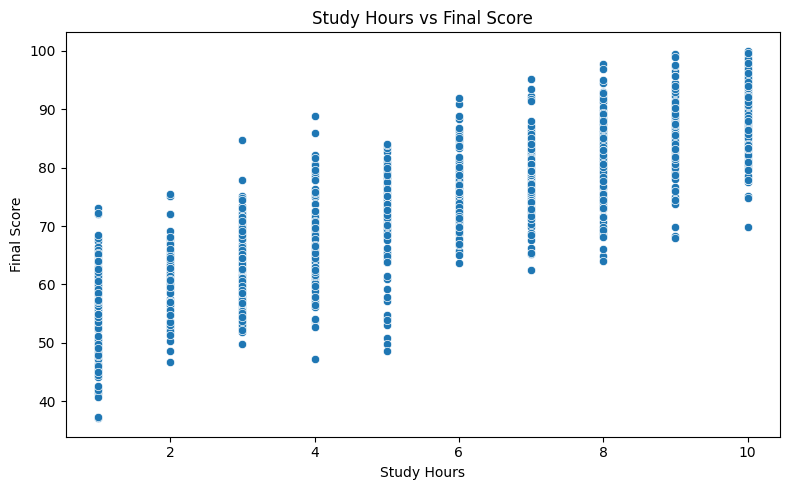

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Score"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.tight_layout()
plt.show()


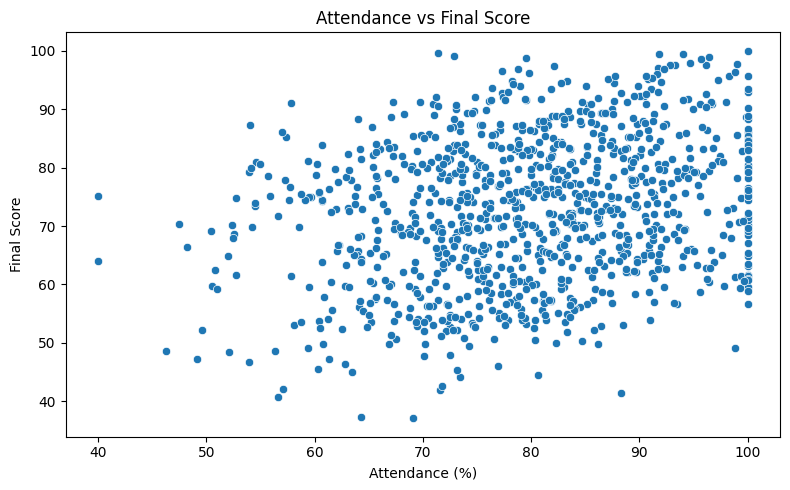

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Score"
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.tight_layout()
plt.show()


In [20]:

numeric_columns = [
    "Study_Hours",
    "Attendance",
    "Assignment_Score",
    "Math_Score",
    "Science_Score",
    "English_Score",
    "Final_Score"
]

correlation = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation)



Correlation Matrix:
                  Study_Hours  Attendance  Assignment_Score  Math_Score  \
Study_Hours          1.000000   -0.066054          0.804667    0.740679   
Attendance          -0.066054    1.000000          0.133534    0.146044   
Assignment_Score     0.804667    0.133534          1.000000    0.657067   
Math_Score           0.740679    0.146044          0.657067    1.000000   
Science_Score        0.727592    0.135007          0.607406    0.584656   
English_Score        0.670481    0.199197          0.566953    0.561440   
Final_Score          0.828347    0.257705          0.762045    0.829830   

                  Science_Score  English_Score  Final_Score  
Study_Hours            0.727592       0.670481     0.828347  
Attendance             0.135007       0.199197     0.257705  
Assignment_Score       0.607406       0.566953     0.762045  
Math_Score             0.584656       0.561440     0.829830  
Science_Score          1.000000       0.529296     0.791242  
Englis

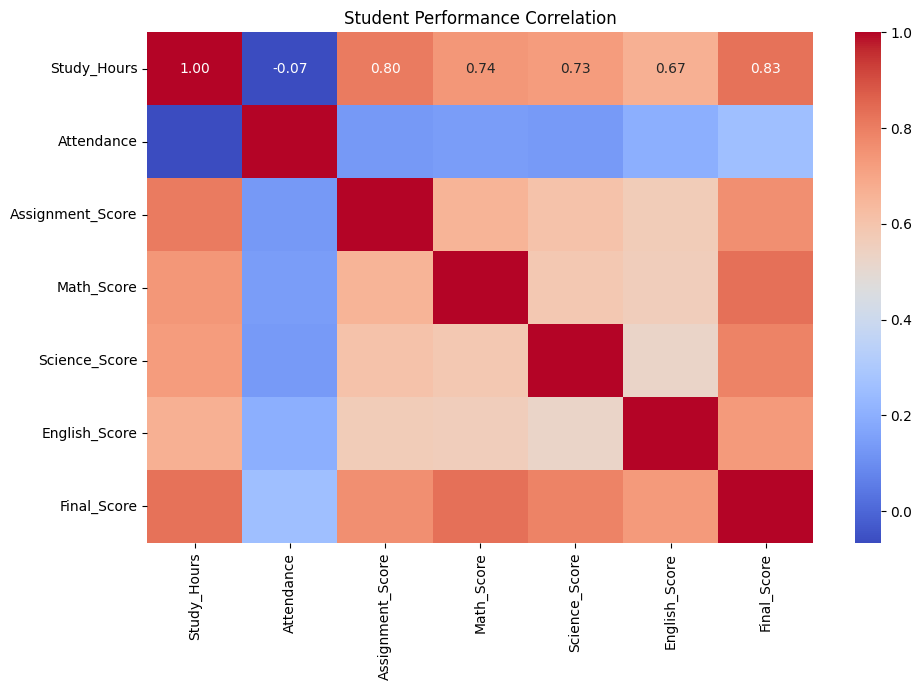

In [21]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Student Performance Correlation")

plt.tight_layout()
plt.show()

In [22]:
weak_students = df[
    df["Final_Score"] < 40
]

print("\nStudents Needing Improvement:")

print(
    weak_students[
        [
            "Student_ID",
            "Study_Hours",
            "Attendance",
            "Final_Score",
            "Performance"
        ]
    ]
)


Students Needing Improvement:
     Student_ID  Study_Hours  Attendance  Final_Score        Performance
266         267            1        69.1         37.1  Needs Improvement
724         725            1        64.3         37.4  Needs Improvement


In [23]:

gender_performance = df.groupby(
    "Gender"
)["Final_Score"].mean()

print("\nGender-wise Average Performance:")
print(gender_performance)


Gender-wise Average Performance:
Gender
Female    71.787349
Male      73.454582
Name: Final_Score, dtype: float64


In [24]:
study_analysis = df.groupby(
    "Study_Hours"
)["Final_Score"].mean()

print("\nAverage Score by Study Hours:")
print(study_analysis)


Average Score by Study Hours:
Study_Hours
1     56.245763
2     60.822892
3     63.744545
4     67.553191
5     71.157009
6     75.835417
7     78.357447
8     81.389000
9     85.024176
10    88.237383
Name: Final_Score, dtype: float64
